In [5]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from pydrake.geometry.optimization import HPolyhedron
from pydrake.solvers import MosekSolver
from pydrake.trajectories import PiecewisePolynomial
from scipy.spatial import ConvexHull
from gcs.bezier import BezierGCS
from gcs.linear import LinearGCS
from gcs.rounding import *

from acd2d.acd2d import ACD2D

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Diamond Obstacle

In [26]:
# Helper function to ensure counter-clockwise order
def ensure_ccw(vertices):
    """Ensure vertices are in counter-clockwise order"""
    vertices = np.asarray(vertices)
    # Calculate signed area
    area = 0.0
    n = len(vertices)
    for i in range(n):
        j = (i + 1) % n
        area += vertices[i, 0] * vertices[j, 1]
        area -= vertices[j, 0] * vertices[i, 1]
    
    # If area is negative, vertices are clockwise - reverse them
    if area < 0:
        return vertices[::-1]
    return vertices

# Helper function to ensure CLOCKWISE order for holes
def ensure_cw(vertices):
    """Ensure vertices are in clockwise order (for holes in ACD2D)"""
    vertices = np.asarray(vertices)
    # Calculate signed area
    area = 0.0
    n = len(vertices)
    for i in range(n):
        j = (i + 1) % n
        area += vertices[i, 0] * vertices[j, 1]
        area -= vertices[j, 0] * vertices[i, 1]
    
    # If area is positive, vertices are counter-clockwise - reverse them
    if area > 0:
        return vertices[::-1]
    return vertices

# Helper to check if polygon is valid
def is_valid_polygon(vertices):
    """Check if polygon is valid (no self-intersection)"""
    try:
        hull = ConvexHull(vertices)
        return True
    except:
        return False


def merge_boundary_obstacles_to_workspace(workspace, obstacles, tolerance=1e-6):
    """
    Merge obstacles that touch or overlap workspace boundary into the workspace as notches.
    
    Args:
        workspace: np.array of workspace vertices (CCW order)
        obstacles: list of np.array obstacle vertices (CW order)
        tolerance: distance tolerance for considering a point on the boundary
    
    Returns:
        new_workspace: modified workspace with notches
        remaining_obstacles: obstacles that don't touch the boundary
    """
    from shapely.geometry import Polygon, LineString, Point
    from shapely.ops import unary_union
    
    workspace_poly = Polygon(workspace)
    workspace_boundary = LineString(list(workspace) + [workspace[0]])
    
    remaining_obstacles = []
    boundary_obstacles = []
    
    for obs in obstacles:
        obs_poly = Polygon(obs)
        
        # Check if obstacle intersects or touches workspace boundary
        if obs_poly.touches(workspace_boundary) or obs_poly.intersects(workspace_boundary):
            # Check if any vertex of obstacle is on workspace boundary
            touches_boundary = False
            for vertex in obs:
                point = Point(vertex)
                if workspace_boundary.distance(point) < tolerance:
                    touches_boundary = True
                    break
            
            if touches_boundary:
                boundary_obstacles.append(obs_poly)
            else:
                remaining_obstacles.append(obs)
        else:
            remaining_obstacles.append(obs)
    
    # If there are boundary obstacles, merge them with workspace
    if boundary_obstacles:
        # Subtract boundary obstacles from workspace to create notches
        new_workspace_poly = workspace_poly
        for obs_poly in boundary_obstacles:
            new_workspace_poly = new_workspace_poly.difference(obs_poly)
        
        # Extract new workspace boundary vertices
        if new_workspace_poly.geom_type == 'Polygon':
            new_workspace = np.array(new_workspace_poly.exterior.coords[:-1])
        else:
            # Handle MultiPolygon case (shouldn't happen but just in case)
            print("Warning: workspace became MultiPolygon, using largest component")
            largest = max(new_workspace_poly.geoms, key=lambda p: p.area)
            new_workspace = np.array(largest.exterior.coords[:-1])
    else:
        new_workspace = workspace
    
    return new_workspace, remaining_obstacles

ACD2D wrapper initialized with executable: /home/dang-khoa/code/motion-planning/gcs-science-robotics/acd2d/build/acd2d
Input file saved to: acd2d_input_1763995073.poly
Decomposed into 14 polygons with 15 cuts.

Polygon 1:
[[1.15886  0.790131]
 [1.31688  0.737455]
 [1.31688  1.31688 ]
 [1.15886  1.31688 ]]

Polygon 2:
[[0.895481 1.21153 ]
 [1.00083  1.31688 ]
 [0.263387 1.31688 ]
 [0.632114 1.21153 ]]

Polygon 3:
[[0.579429 1.21153 ]
 [0.591127 1.22323 ]
 [0.263377 1.31687 ]
 [0.263377 1.23261 ]
 [0.368738 1.21153 ]]

Polygon 4:
[[0.632104 1.21152 ]
 [0.591127 1.22323 ]
 [0.579429 1.21153 ]
 [0.579429 0.737455]
 [0.632104 0.68478 ]]

Polygon 5:
[[0.368728  0.579429 ]
 [0.263377  0.632104 ]
 [0.263377  0.       ]
 [1.00322   0.       ]
 [1.00083   0.0526754]]

Polygon 6:
[[ 0.00000e+00  1.31688e+00]
 [ 0.00000e+00 -2.92407e-16]
 [ 1.05351e-01  6.84780e-01]
 [ 1.05351e-01  1.31688e+00]]

Polygon 7:
[[1.26421  0.316052]
 [1.31688  0.316052]
 [1.31688  0.68478 ]
 [1.00083  0.68478 ]
 [0.948

ValueError: Source vertex is not connected.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


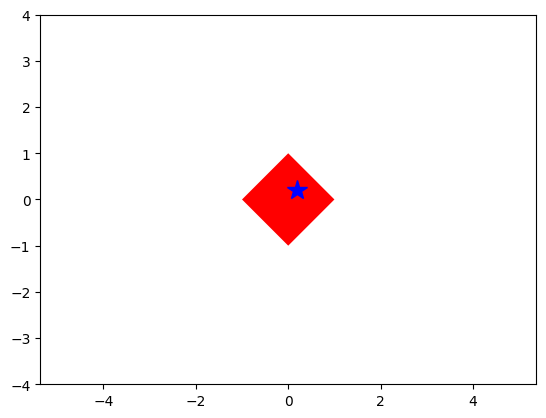

In [ ]:
x_start = np.array([0., -2.])
x_goal = np.array([0., 2.])
convex_relaxation = True

A_bl = np.array([[-1, 0], [0, -1], [1, 1]])
A_br = np.array([[1, 0], [0, -1], [-1, 1]])
A_tl = np.array([[-1, 0], [0, 1], [1, -1]])
A_tr = np.array([[1, 0], [0, 1], [-1, -1]])
b = np.array([3, 3, -1])

# Setup
acd = ACD2D()
acd.set_parameters(tau=0.05)

# Environment
# workspace = np.array([[-3, -3], [3, -3], [3, 3], [-3, 3]])
# obstacle = np.array([[1, 0], [0, 1], [-1, 0], [0, -1]])

# regions = [
#     HPolyhedron(A_bl, b),
#     HPolyhedron(A_br, b),
#     HPolyhedron(A_tl, b),
#     HPolyhedron(A_tr, b),
# ]

# Setup
x_start = np.array([0.2, 0.2])
x_goal = np.array([4.8, 4.8])
convex_relaxation = True

workspace = np.array([[0, 0], [5, 0], [5, 5], [0, 5]])
# Original obstacles
obstacles = [
    np.array([
        [3.4, 2.6],
        [3.4, 4.6],
        [2.4, 4.6],
        [2.4, 2.6],
        [1.4, 2.2],
        [3.8, 0.2],
        [4.8, 1.2],
    ]),
    np.array([[1.4, 2.8], [2.2, 2.8], [2.2, 4.6], [1.4, 4.6]]),
    np.array([[1.0, 2.6], [1.0, 5.0], [0.4, 5.0], [0.4, 2.6]]),
    np.array([[1.0, 2.4], [1.0, 0.0], [0.4, 0.0], [0.4, 2.4]]),
    np.array([[3.8, 3.0], [3.8, 5.0], [4.4, 5.0], [4.4, 3.0]]),
    np.array([[3.8, 2.8], [3.8, 2.6], [5.0, 2.6], [5.0, 2.8]]),
]

regions, result = acd.decompose_to_hpolyhedron(workspace, holes=obstacles)


plt.figure()
plt.plot(x_start[0], x_start[1], 'b*', markersize=15)
plt.plot(x_goal[0], x_goal[1], 'g*', markersize=15)
plt.fill([1, 0, -1, 0], [0, 1, 0, -1], 'r')
# ax[0].fill([1, 1, -1, -1], [-1, 1, 1, -1], 'r')
plt.axis('equal')
plt.gca().set_xlim(-4, 4)
plt.gca().set_ylim(-4, 4)

l_gcs = LinearGCS(regions)
l_gcs.addSourceTarget(x_start, x_goal)
l_gcs.setSolver(MosekSolver())
waypoints = l_gcs.SolvePath(convex_relaxation)[0]
t_knots = np.linspace(0, 1,  waypoints.shape[1])
lin_traj = PiecewisePolynomial.FirstOrderHold(t_knots, waypoints)

samples = np.linspace(lin_traj.start_time(), lin_traj.end_time())
values = np.squeeze([lin_traj.value(s) for s in samples])
plt.plot(values[:, 0], values[:, 1], "m-")

b_gcs = BezierGCS(regions, order=5, continuity=2)
b_gcs.addTimeCost(1)
b_gcs.addPathLengthCost(1)
b_gcs.addSourceTarget(x_start, x_goal)
b_gcs.setSolver(MosekSolver())
bezier_traj = b_gcs.SolvePath(convex_relaxation)[0]

samples = np.linspace(bezier_traj.start_time(), bezier_traj.end_time())
values = np.squeeze([bezier_traj.value(s) for s in samples])
plt.plot(values[:, 0], values[:, 1], "c-")

# Square Obstacle

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.
INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 2 unique paths, discarded 98 duplicate paths.
INFO:drake:Finished 2 rounding solutions with MOSEK.
INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.
INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and rounding.
INFO:drake:Found 2 unique paths, discarded 98 duplicate paths.
INFO:drake:Finished 2 rounding solutions with MOSEK.
INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.
INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


Problem
  Name                   :                 
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 1255            
  Affine conic cons.     : 45 (135 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 392             
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 376
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 1
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes     

INFO:drake:Solved GCS shortest path using MOSEK with convex_relaxation=true and preprocessing=false and no rounding.


13  1.4e-07  2.3e-09  1.2e-12  1.00e+00   4.828442469e+00   4.828442435e+00   5.8e-10  0.01  
Optimizer terminated. Time: 0.01    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 4.8284424687e+00    nrm: 1e+03    Viol.  con: 2e-09    var: 0e+00    acc: 3e-09  
  Dual.    obj: 4.8284424354e+00    nrm: 2e+00    Viol.  con: 7e-10    var: 3e-09    acc: 0e+00  


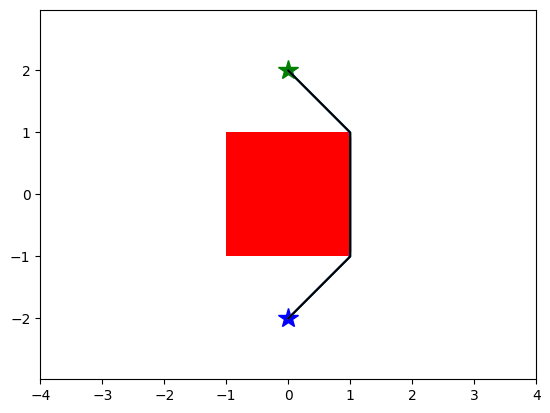

In [6]:
x_start = np.array([0., -2.])
x_goal = np.array([0., 2.])
convex_relaxation = True

regions = [
    HPolyhedron.MakeBox([-4, -4],[4, -1]), # Bottom
    HPolyhedron.MakeBox([-4, -4],[-1, 4]), # Left
    HPolyhedron.MakeBox([1, -4],[4, 4]),   # Right
    HPolyhedron.MakeBox([-4, 1],[4, 4]),   # Top
]


plt.figure()
plt.plot(x_start[0], x_start[1], 'b*', markersize=15)
plt.plot(x_goal[0], x_goal[1], 'g*', markersize=15)
plt.fill([1, 1, -1, -1], [-1, 1, 1, -1], 'r')
plt.axis('equal')
plt.gca().set_xlim(-4, 4)
plt.gca().set_ylim(-4, 4)

l_gcs = LinearGCS(regions)
l_gcs.addSourceTarget(x_start, x_goal)
l_gcs.setSolver(MosekSolver())
waypoints = l_gcs.SolvePath(convex_relaxation)[0]
t_knots = np.linspace(0, 1,  waypoints.shape[1])
lin_traj = PiecewisePolynomial.FirstOrderHold(t_knots, waypoints)

samples = np.linspace(lin_traj.start_time(), lin_traj.end_time())
values = np.squeeze([lin_traj.value(s) for s in samples])
plt.plot(values[:, 0], values[:, 1], "m-")

b_gcs = BezierGCS(regions, order=5, continuity=2)
b_gcs.addTimeCost(1)
b_gcs.addPathLengthCost(1)
b_gcs.addSourceTarget(x_start, x_goal)
b_gcs.setPaperSolverOptions()
b_gcs.setSolver(MosekSolver())
bezier_traj = b_gcs.SolvePath(convex_relaxation)[0]

samples = np.linspace(bezier_traj.start_time(), bezier_traj.end_time())
values = np.squeeze([bezier_traj.value(s) for s in samples])
plt.plot(values[:, 0], values[:, 1], "c-")

# Alternate rounding strategy
b_gcs = BezierGCS(regions, order=5, continuity=2)
b_gcs.addTimeCost(1)
b_gcs.addPathLengthCost(1)
b_gcs.addSourceTarget(x_start, x_goal)
b_gcs.setPaperSolverOptions()
b_gcs.setSolver(MosekSolver())
b_gcs.setRoundingStrategy([greedyForwardPathSearch, greedyBackwardPathSearch])
bezier_traj = b_gcs.SolvePath(convex_relaxation)[0]

samples = np.linspace(bezier_traj.start_time(), bezier_traj.end_time())
values = np.squeeze([bezier_traj.value(s) for s in samples])
plt.plot(values[:, 0], values[:, 1], "k-")